# EDA – Knock com Hidrogênio

Notebook para a disciplina **ADEC – Análise Exploratória de Dados e Engenharia de Características**.

**Objetivo:** ler a base `Resultados_H2.csv`, identificar as features e unidades nas duas primeiras linhas e executar a EDA solicitada: estatísticas, qualidade, distribuição, correlações e gráficos de knock.

> **Observação importante:** a base contém nomes repetidos de colunas. Por isso, o notebook mantém uma tabela com *feature original*, *unidade* e *nome interno único*. Para as análises principais são usados os campos iniciais de resumo de ensaio: `ECU_Lambda`, `ECU_AIGN`, `CA50`, `IMEPn`, `MAPO`, `SEPO` e `DKI` (usado como índice de knock, quando `KI` não existe explicitamente).


In [1]:
# ============================================================
# 0. Bibliotecas e caminhos
# ============================================================
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# Ajuste o caminho se o arquivo estiver em outra pasta no seu VSCode.
ARQUIVO_DADOS = Path("Resultados_H2.csv")
PASTA_SAIDA = Path("resultados_eda")
PASTA_SAIDA.mkdir(exist_ok=True)

# Configurações de visualização
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 110


## 1. Leitura da base e inspeção das linhas de feature/unidade

A leitura é feita sem cabeçalho (`header=None`) porque a linha 0 contém o nome das features e a linha 1 contém as unidades.

In [2]:
# ============================================================
# 1. Leitura robusta do CSV
# ============================================================
def ler_csv_com_codificacao(caminho: Path) -> pd.DataFrame:
    """Tenta codificações comuns em arquivos exportados no Windows."""
    erros = []
    for codificacao in ("utf-8-sig", "cp1252", "latin1"):
        try:
            return pd.read_csv(
                caminho,
                sep=";",
                header=None,
                encoding=codificacao,
                low_memory=False
            )
        except UnicodeDecodeError as erro:
            erros.append(f"{codificacao}: {erro}")
    raise UnicodeError("Não foi possível decodificar o CSV. " + " | ".join(erros))

if not ARQUIVO_DADOS.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {ARQUIVO_DADOS.resolve()}\n"
        "Coloque Resultados_H2.csv na mesma pasta deste notebook ou ajuste ARQUIVO_DADOS."
    )

base_bruta = ler_csv_com_codificacao(ARQUIVO_DADOS)

print(f"Dimensão bruta (inclui as linhas de feature e unidade): {base_bruta.shape}")
print("\nPrimeiras 3 linhas e 5 primeiras colunas:")
display(base_bruta.iloc[:3, :5])


Dimensão bruta (inclui as linhas de feature e unidade): (85, 260)

Primeiras 3 linhas e 5 primeiras colunas:


,0,1,2,3,4
0,Descri‡Æo,MP,Knock,Valido,RC
1,NaN,NaN,NaN,NaN,-
2,Lambda Sweep para RC 7.92,2,0,1,7.92


In [3]:
# ============================================================
# 2. Separar: nome da feature, unidade e dados experimentais
# ============================================================
LINHA_FEATURES = 0
LINHA_UNIDADES = 1
LINHA_INICIO_DADOS = 2

features_originais = base_bruta.iloc[LINHA_FEATURES].fillna("").astype(str).str.strip()
unidades = base_bruta.iloc[LINHA_UNIDADES].fillna("").astype(str).str.strip()

# Gera nomes únicos sem perder o nome original.
def tornar_unico(nomes):
    contagem = {}
    nomes_unicos = []
    for nome in nomes:
        nome = nome if nome else "coluna_sem_nome"
        contagem[nome] = contagem.get(nome, 0) + 1
        sufixo = "" if contagem[nome] == 1 else f"__{contagem[nome]}"
        nomes_unicos.append(nome + sufixo)
    return nomes_unicos

features_unicas = tornar_unico(features_originais.tolist())

dicionario_features = pd.DataFrame({
    "posição": range(len(features_originais)),
    "feature_original": features_originais,
    "unidade": unidades,
    "feature_interna": features_unicas
})

# Resposta direta ao item 2 da tarefa: nomes, unidades e cinco primeiras colunas.
print("Tabela das 5 primeiras features e unidades:")
display(dicionario_features.iloc[:5])

print("\nCinco primeiras colunas da base, incluindo feature e unidade:")
display(base_bruta.iloc[:2, :5])

# Cria a base de dados limpa, com os nomes internos únicos.
dados = base_bruta.iloc[LINHA_INICIO_DADOS:].copy()
dados.columns = features_unicas
dados = dados.dropna(how="all").reset_index(drop=True)

print(f"\nDimensão da base experimental: {dados.shape[0]} linhas × {dados.shape[1]} colunas")


Tabela das 5 primeiras features e unidades:


,posição,feature_original,unidade,feature_interna
0,0,Descri‡Æo,,Descri‡Æo
1,1,MP,,MP
2,2,Knock,,Knock
3,3,Valido,,Valido
4,4,RC,-,RC



Cinco primeiras colunas da base, incluindo feature e unidade:


,0,1,2,3,4
0,Descri‡Æo,MP,Knock,Valido,RC
1,NaN,NaN,NaN,NaN,-



Dimensão da base experimental: 83 linhas × 260 colunas


## 2. Preparação dos tipos de dados

O CSV mistura campos textuais, categóricos e numéricos. Esta célula tenta converter automaticamente os valores numéricos e preserva as colunas textuais.

In [4]:
# ============================================================
# 3. Converter colunas para numérico quando apropriado
# ============================================================
def converter_para_numerico(serie: pd.Series) -> pd.Series:
    """Converte números armazenados como texto; mantém NaN para valores não numéricos."""
    texto = serie.astype("string").str.strip()
    texto = texto.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "-": pd.NA})
    return pd.to_numeric(texto.str.replace(",", ".", regex=False), errors="coerce")

for coluna in dados.columns:
    convertido = converter_para_numerico(dados[coluna])
    # Converte somente quando pelo menos 70% dos valores não vazios puderem ser numéricos.
    nao_vazios = dados[coluna].notna().sum()
    if nao_vazios > 0 and convertido.notna().sum() / nao_vazios >= 0.70:
        dados[coluna] = convertido

print("Tipos das primeiras 20 colunas:")
display(dados.dtypes.head(20).to_frame("tipo"))


Tipos das primeiras 20 colunas:


,tipo
Descri‡Æo,object
MP,Int64
Knock,Int64
Valido,Int64
RC,Float64
Missfire,Float64
ECU_Lambda,Float64
Comb_Dur3,Float64
CA_(dP/dCA)max,Float64
(dP/dCA)max,Float64


## 3. Seleção das variáveis principais da EDA

A seleção abaixo usa aliases para lidar com diferenças de nomenclatura. Para o gráfico solicitado de **IMEP × KI**, o notebook usa `IMEPn` como IMEP e `DKI` como índice de knock quando a coluna `KI` não estiver presente.

In [5]:
# ============================================================
# 4. Localizar variáveis principais por aliases
# ============================================================
def localizar_coluna(candidatas, obrigatoria=True):
    for candidata in candidatas:
        if candidata in dados.columns:
            return candidata
    if obrigatoria:
        raise KeyError(f"Nenhuma das colunas foi encontrada: {candidatas}")
    return None

colunas_eda = {
    "Knock": localizar_coluna(["Knock"]),
    "Valido": localizar_coluna(["Valido"], obrigatoria=False),
    "RC": localizar_coluna(["RC", "rc"]),
    "Lambda": localizar_coluna(["ECU_Lambda"]),
    "Avanco": localizar_coluna(["ECU_AIGN"]),
    "CA50": localizar_coluna(["CA50"]),
    "IMEP": localizar_coluna(["IMEPn", "IMEPg", "IMEP"]),
    "MAPO": localizar_coluna(["MAPO"]),
    "SEPO": localizar_coluna(["SEPO"]),
    "KI": localizar_coluna(["KI", "DKI"], obrigatoria=False),
}

print("Variáveis selecionadas para a EDA:")
display(pd.DataFrame(colunas_eda.items(), columns=["Variável da análise", "Coluna na base"]))


Variáveis selecionadas para a EDA:


,Variável da análise,Coluna na base
0,Knock,Knock
1,Valido,Valido
2,RC,RC
3,Lambda,ECU_Lambda
4,Avanco,ECU_AIGN
5,CA50,CA50
6,IMEP,IMEPn
7,MAPO,MAPO
8,SEPO,SEPO
9,KI,DKI


In [6]:
# ============================================================
# 5. Criar uma tabela compacta para os gráficos principais
# ============================================================
base_eda = pd.DataFrame({
    nome: dados[coluna] if coluna is not None else np.nan
    for nome, coluna in colunas_eda.items()
})

# Knock é uma variável de classe; converte para 0/1 quando possível.
base_eda["Knock"] = pd.to_numeric(base_eda["Knock"], errors="coerce")

# Filtra apenas ensaios válidos quando a variável existir.
if "Valido" in base_eda.columns and base_eda["Valido"].notna().any():
    n_antes = len(base_eda)
    base_eda_valida = base_eda[base_eda["Valido"] == 1].copy()
    print(f"Ensaios válidos: {len(base_eda_valida)} de {n_antes}")
else:
    base_eda_valida = base_eda.copy()
    print("Coluna Valido indisponível ou sem valores; todos os ensaios foram mantidos.")

display(base_eda_valida.head())


Ensaios válidos: 79 de 83


,Knock,Valido,RC,Lambda,Avanco,CA50,IMEP,MAPO,SEPO,KI
0,0,1,7.9200,1.0000,0.5000,8.5139,4.5181,0.0267,0.7828,NaN
1,0,1,7.9200,1.0000,0.5000,8.4634,4.5402,0.0399,0.7047,NaN
2,0,1,7.9200,0.8977,0.0000,8.5357,4.5240,0.0309,0.7973,NaN
3,0,1,7.9200,0.8883,0.0000,8.4491,4.5107,0.0277,0.9379,NaN
4,0,1,7.9200,0.7991,0.0000,8.0658,4.4989,0.0334,1.0360,NaN


## 4. Estatísticas descritivas

Média, mediana, mínimo, máximo e desvio padrão para cada variável numérica.

In [7]:
# ============================================================
# 6. Estatísticas descritivas de todas as variáveis numéricas
# ============================================================
numericas = dados.select_dtypes(include="number")
estatisticas = pd.DataFrame({
    "média": numericas.mean(),
    "mediana": numericas.median(),
    "mínimo": numericas.min(),
    "máximo": numericas.max(),
    "desvio_padrão": numericas.std(),
    "n_válidos": numericas.count()
}).sort_index()

print(f"Número de variáveis numéricas: {len(estatisticas)}")
display(estatisticas)
estatisticas.to_csv(PASTA_SAIDA / "estatisticas_descritivas.csv", encoding="utf-8-sig")


Número de variáveis numéricas: 246


,média,mediana,mínimo,máximo,desvio_padrão,n_válidos
(dAHRR/dCA)max,19.2665,16.9914,2.0799,59.2106,13.8135,83
(dP/dCA)max,5.6603,4.4626,1.2638,14.7234,3.4990,83
(dP/dCA)max__2,5.6603,4.4626,1.2638,14.7234,3.4990,83
(dP/dt)max,4.0751,3.2141,0.9101,10.5829,2.5179,83
(dP/dt)max__2,4.0751,3.2141,0.9101,10.5829,2.5179,83
...,...,...,...,...,...,...
po,0.0000,0.0000,0.0000,0.0000,0.0000,83
r,55.5400,55.5400,55.5400,55.5400,0.0000,83
rc,10.3778,9.9200,7.9200,14.9200,1.9400,83
rc_eff,9.9798,9.5414,7.6263,14.3292,1.8576,83


## 5. Qualidade dos dados

São verificadas células ausentes, linhas duplicadas e exemplos de pontos fisicamente incoerentes. Os limites abaixo são verificações iniciais de engenharia e devem ser confirmados com a configuração experimental.

In [8]:
# ============================================================
# 7. Qualidade: faltantes, duplicados e coerência física
# ============================================================
faltantes = pd.DataFrame({
    "faltantes": dados.isna().sum(),
    "percentual_faltante": 100 * dados.isna().mean()
}).sort_values("faltantes", ascending=False)

linhas_duplicadas = dados.duplicated().sum()

print(f"Linhas totalmente duplicadas: {linhas_duplicadas}")
print("\nTop 20 colunas com maior quantidade de dados faltantes:")
display(faltantes.head(20))

# Regras iniciais de coerência. Ajuste-as de acordo com os limites do banco de ensaios.
regras_incoerencia = {
    "Knock fora de 0/1": ~base_eda["Knock"].isin([0, 1]) & base_eda["Knock"].notna(),
    "RC não positiva": base_eda["RC"].notna() & (base_eda["RC"] <= 0),
    "Lambda não positiva": base_eda["Lambda"].notna() & (base_eda["Lambda"] <= 0),
    "IMEP não positiva": base_eda["IMEP"].notna() & (base_eda["IMEP"] <= 0),
    "MAPO negativa": base_eda["MAPO"].notna() & (base_eda["MAPO"] < 0),
    "SEPO negativa": base_eda["SEPO"].notna() & (base_eda["SEPO"] < 0),
}

incoerencias = pd.DataFrame({nome: mascara for nome, mascara in regras_incoerencia.items()})
resumo_incoerencias = incoerencias.sum().to_frame("quantidade")
print("\nResumo de pontos potencialmente incoerentes:")
display(resumo_incoerencias)

indices_incoerentes = incoerencias.any(axis=1)
print(f"Linhas com ao menos uma incoerência: {indices_incoerentes.sum()}")
if indices_incoerentes.any():
    display(base_eda.loc[indices_incoerentes].head(10))


Linhas totalmente duplicadas: 0

Top 20 colunas com maior quantidade de dados faltantes:


,faltantes,percentual_faltante
coluna_sem_nome,83,100.0000
IMPO,83,100.0000
AEPO,83,100.0000
AEFD,83,100.0000
DKI,83,100.0000
IMPG,83,100.0000
MAHRO,83,100.0000
SEHRO,83,100.0000
AEHRO,83,100.0000
DMP,83,100.0000



Resumo de pontos potencialmente incoerentes:


,quantidade
Knock fora de 0/1,0
RC não positiva,0
Lambda não positiva,0
IMEP não positiva,0
MAPO negativa,0
SEPO negativa,0


Linhas com ao menos uma incoerência: 0


## 6. Boxplots das variáveis solicitadas

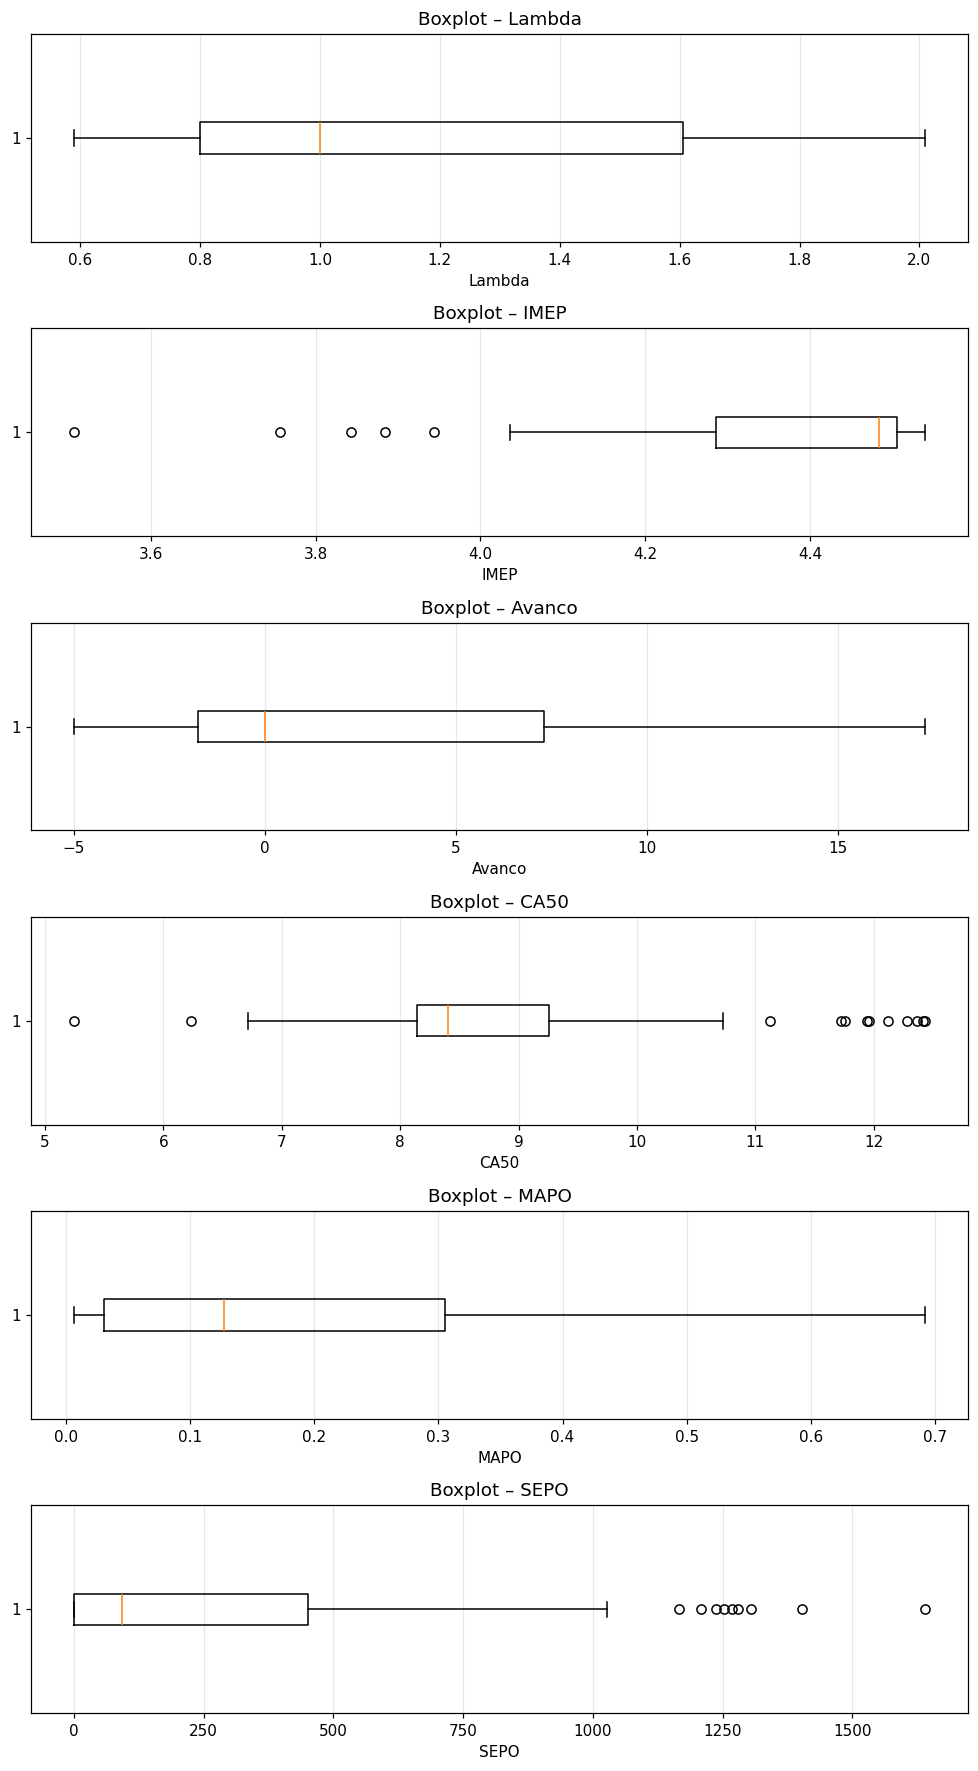

In [9]:
# ============================================================
# 8. Boxplots: Lambda, IMEP, avanço, CA50, MAPO, SEPO e KI
# ============================================================
variaveis_boxplot = ["Lambda", "IMEP", "Avanco", "CA50", "MAPO", "SEPO", "KI"]
variaveis_boxplot = [v for v in variaveis_boxplot if v in base_eda_valida.columns and base_eda_valida[v].notna().any()]

fig, eixos = plt.subplots(len(variaveis_boxplot), 1, figsize=(9, 2.7 * len(variaveis_boxplot)))
if len(variaveis_boxplot) == 1:
    eixos = [eixos]

for eixo, variavel in zip(eixos, variaveis_boxplot):
    valores = base_eda_valida[variavel].dropna()
    eixo.boxplot(valores, vert=False)
    eixo.set_title(f"Boxplot – {variavel}")
    eixo.set_xlabel(variavel)
    eixo.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(PASTA_SAIDA / "boxplots_variaveis_principais.png", bbox_inches="tight")
plt.show()


## 7. Histogramas e desbalanceamento de knock

Distribuição da classe Knock:


,contagem,percentual
Knock,,
0,41,51.8987
1,38,48.1013


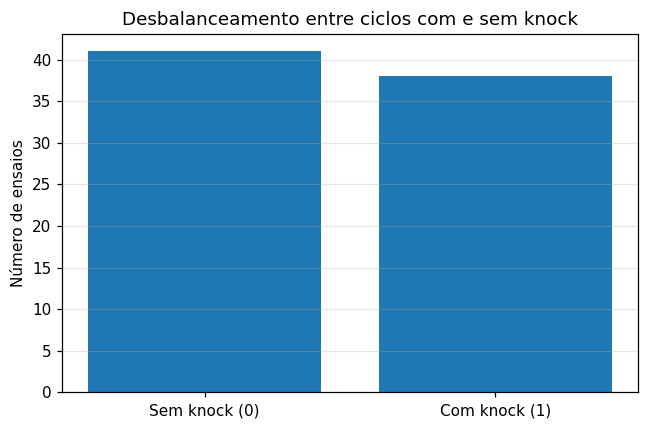

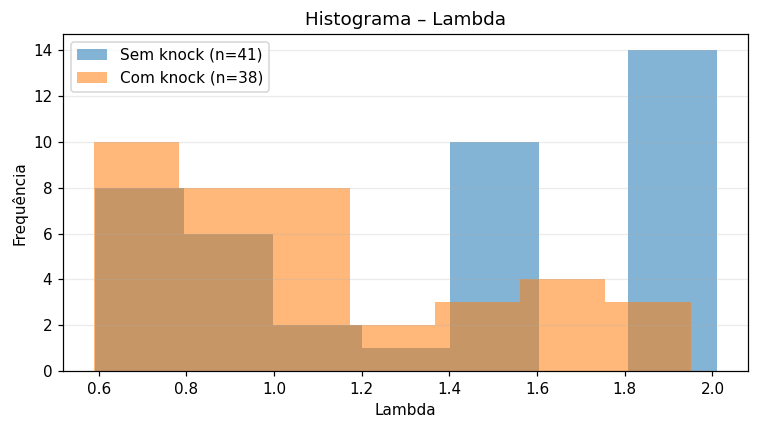

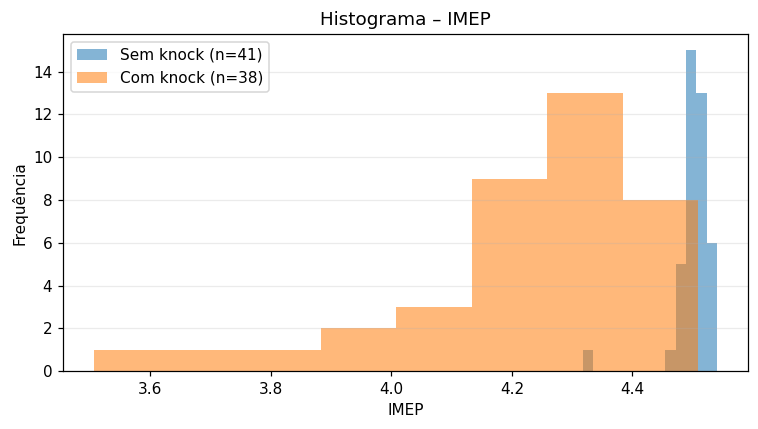

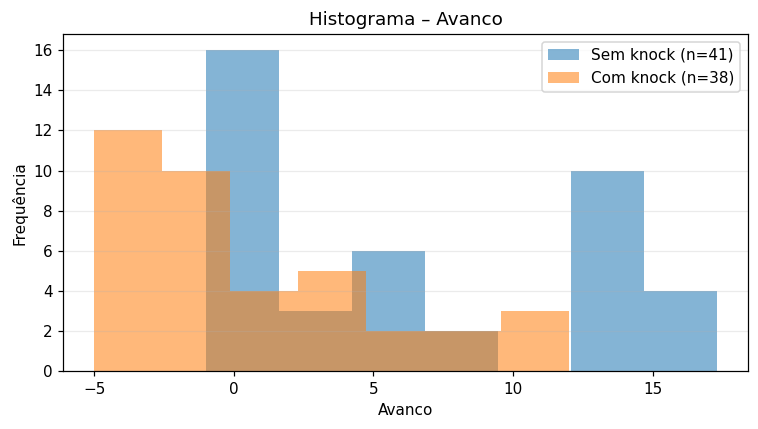

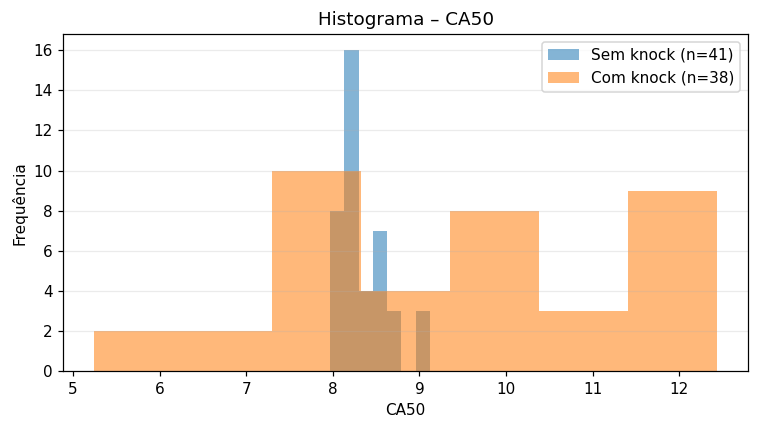

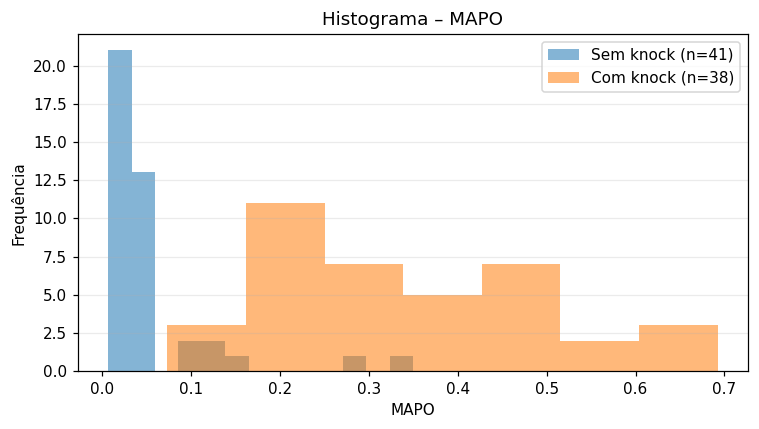

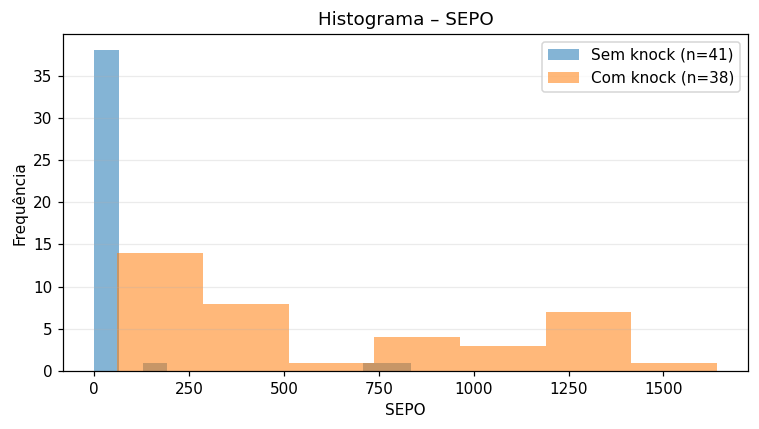

In [10]:
# ============================================================
# 9. Distribuições e desbalanceamento das classes de knock
# ============================================================
contagem_knock = base_eda_valida["Knock"].value_counts(dropna=False).sort_index()
percentual_knock = 100 * base_eda_valida["Knock"].value_counts(normalize=True, dropna=False).sort_index()
resumo_knock = pd.DataFrame({"contagem": contagem_knock, "percentual": percentual_knock})

print("Distribuição da classe Knock:")
display(resumo_knock)

fig, eixo = plt.subplots(figsize=(6, 4))
rotulos = ["Sem knock (0)" if x == 0 else "Com knock (1)" if x == 1 else "Ausente" for x in contagem_knock.index]
eixo.bar(rotulos, contagem_knock.values)
eixo.set_title("Desbalanceamento entre ciclos com e sem knock")
eixo.set_ylabel("Número de ensaios")
eixo.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "desbalanceamento_knock.png", bbox_inches="tight")
plt.show()

# Histogramas das variáveis contínuas principais, separados por ocorrência de knock.
variaveis_hist = ["Lambda", "IMEP", "Avanco", "CA50", "MAPO", "SEPO", "KI"]
variaveis_hist = [v for v in variaveis_hist if v in base_eda_valida.columns and base_eda_valida[v].notna().any()]

for variavel in variaveis_hist:
    fig, eixo = plt.subplots(figsize=(7, 4))
    for classe, rotulo in [(0, "Sem knock"), (1, "Com knock")]:
        valores = base_eda_valida.loc[base_eda_valida["Knock"] == classe, variavel].dropna()
        if len(valores):
            eixo.hist(valores, bins="auto", alpha=0.55, label=f"{rotulo} (n={len(valores)})")
    eixo.set_title(f"Histograma – {variavel}")
    eixo.set_xlabel(variavel)
    eixo.set_ylabel("Frequência")
    eixo.legend()
    eixo.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PASTA_SAIDA / f"histograma_{variavel}.png", bbox_inches="tight")
    plt.show()


## 8. Correlações de Pearson e Spearman

Pearson avalia relações lineares; Spearman é baseada em postos e é mais robusta para relações monotônicas não lineares.

Matriz de correlação de Pearson:


,Knock,RC,Lambda,Avanco,CA50,IMEP,MAPO,SEPO
Knock,1.0000,0.3539,-0.2928,-0.4480,0.3791,-0.6624,0.7745,0.6352
RC,0.3539,1.0000,0.5014,0.3390,-0.0496,-0.4736,0.5329,0.4171
Lambda,-0.2928,0.5014,1.0000,0.9479,-0.4625,0.1415,-0.1799,-0.1627
Avanco,-0.4480,0.3390,0.9479,1.0000,-0.5982,0.2930,-0.3877,-0.3580
CA50,0.3791,-0.0496,-0.4625,-0.5982,1.0000,-0.3385,0.4404,0.4711
IMEP,-0.6624,-0.4736,0.1415,0.2930,-0.3385,1.0000,-0.8962,-0.8328
MAPO,0.7745,0.5329,-0.1799,-0.3877,0.4404,-0.8962,1.0000,0.9062
SEPO,0.6352,0.4171,-0.1627,-0.3580,0.4711,-0.8328,0.9062,1.0000



Matriz de correlação de Spearman:


,Knock,RC,Lambda,Avanco,CA50,IMEP,MAPO,SEPO
Knock,1.0000,0.3895,-0.2536,-0.4828,0.2533,-0.8077,0.8121,0.8066
RC,0.3895,1.0000,0.3746,0.1540,0.0974,-0.4685,0.5787,0.4991
Lambda,-0.2536,0.3746,1.0000,0.8943,-0.3185,0.2264,-0.3250,-0.3863
Avanco,-0.4828,0.1540,0.8943,1.0000,-0.5632,0.4107,-0.5471,-0.6010
CA50,0.2533,0.0974,-0.3185,-0.5632,1.0000,-0.1688,0.2557,0.2792
IMEP,-0.8077,-0.4685,0.2264,0.4107,-0.1688,1.0000,-0.8036,-0.7895
MAPO,0.8121,0.5787,-0.3250,-0.5471,0.2557,-0.8036,1.0000,0.9788
SEPO,0.8066,0.4991,-0.3863,-0.6010,0.2792,-0.7895,0.9788,1.0000


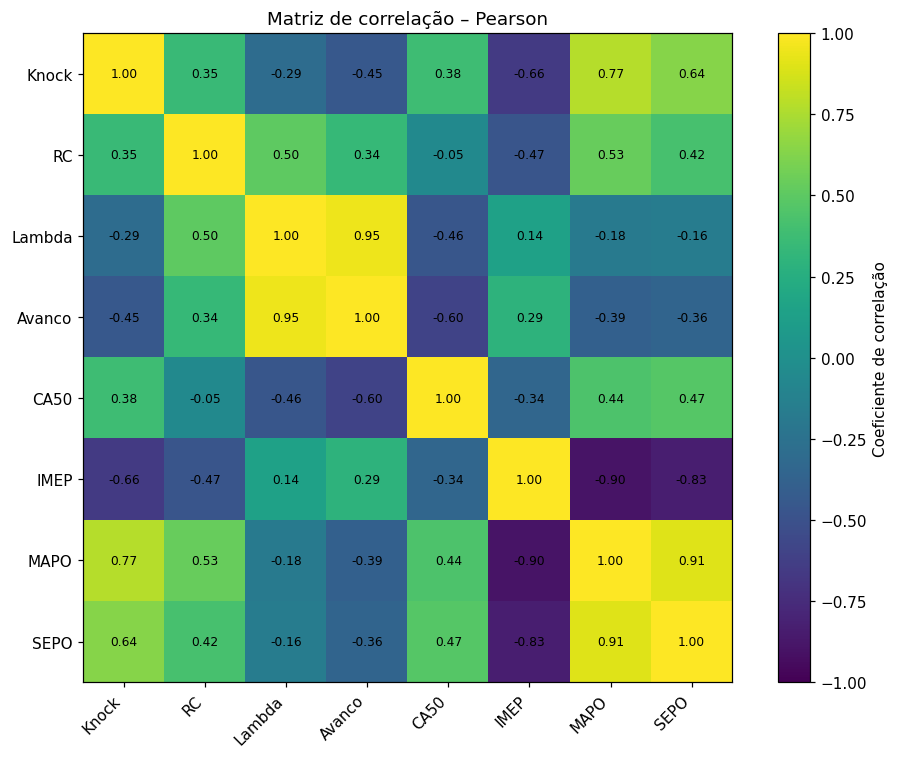

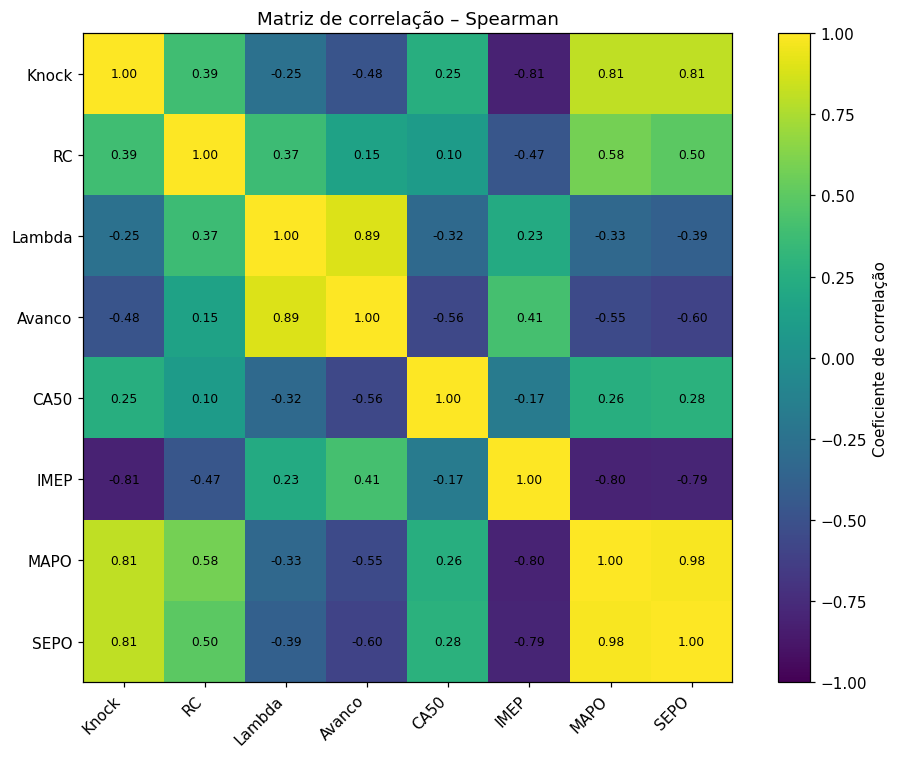

In [11]:
# ============================================================
# 10. Matrizes de correlação – Pearson e Spearman
# ============================================================
variaveis_corr = ["Knock", "RC", "Lambda", "Avanco", "CA50", "IMEP", "MAPO", "SEPO", "KI"]
variaveis_corr = [v for v in variaveis_corr if v in base_eda_valida.columns and base_eda_valida[v].notna().any()]

matriz_pearson = base_eda_valida[variaveis_corr].corr(method="pearson")
matriz_spearman = base_eda_valida[variaveis_corr].corr(method="spearman")

print("Matriz de correlação de Pearson:")
display(matriz_pearson)
print("\nMatriz de correlação de Spearman:")
display(matriz_spearman)

matriz_pearson.to_csv(PASTA_SAIDA / "correlacao_pearson.csv", encoding="utf-8-sig")
matriz_spearman.to_csv(PASTA_SAIDA / "correlacao_spearman.csv", encoding="utf-8-sig")

def plotar_matriz(matriz, titulo, arquivo):
    fig, eixo = plt.subplots(figsize=(9, 7))
    imagem = eixo.imshow(matriz, vmin=-1, vmax=1)
    eixo.set_xticks(range(len(matriz.columns)), matriz.columns, rotation=45, ha="right")
    eixo.set_yticks(range(len(matriz.index)), matriz.index)
    eixo.set_title(titulo)
    barra = plt.colorbar(imagem, ax=eixo)
    barra.set_label("Coeficiente de correlação")
    for i in range(len(matriz.index)):
        for j in range(len(matriz.columns)):
            eixo.text(j, i, f"{matriz.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(PASTA_SAIDA / arquivo, bbox_inches="tight")
    plt.show()

plotar_matriz(matriz_pearson, "Matriz de correlação – Pearson", "matriz_pearson.png")
plotar_matriz(matriz_spearman, "Matriz de correlação – Spearman", "matriz_spearman.png")


## 9. Gráficos de dispersão solicitados

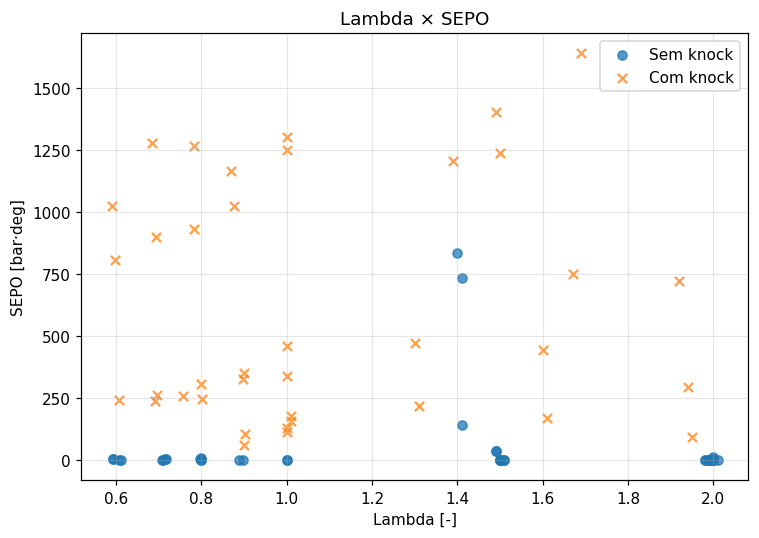

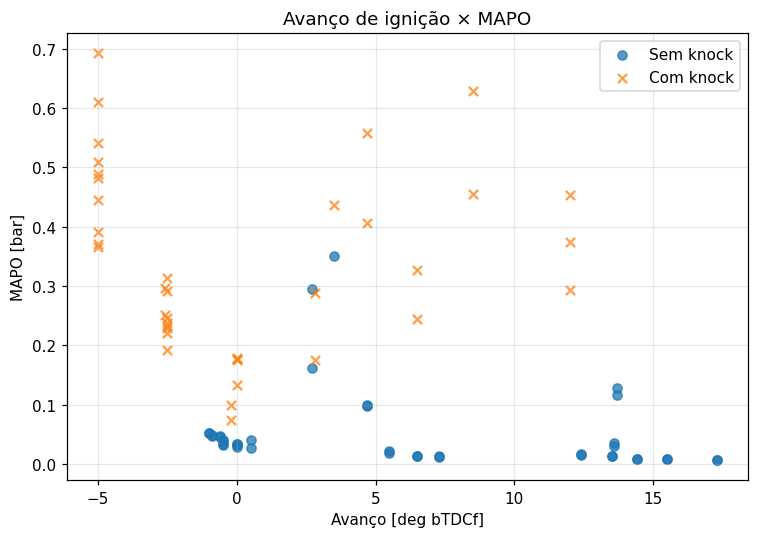

Ocorrência de knock por relação de compressão:


,RC,n_ensaios,n_knock,taxa_knock,taxa_knock_pct
0,7.9200,14,0,0.0000,0.0000
1,8.9200,16,6,0.3750,37.5000
2,9.9200,16,12,0.7500,75.0000
3,10.9200,18,11,0.6111,61.1111
4,11.9200,4,2,0.5000,50.0000
5,12.9200,4,2,0.5000,50.0000
6,13.9200,4,2,0.5000,50.0000
7,14.9200,3,3,1.0000,100.0000


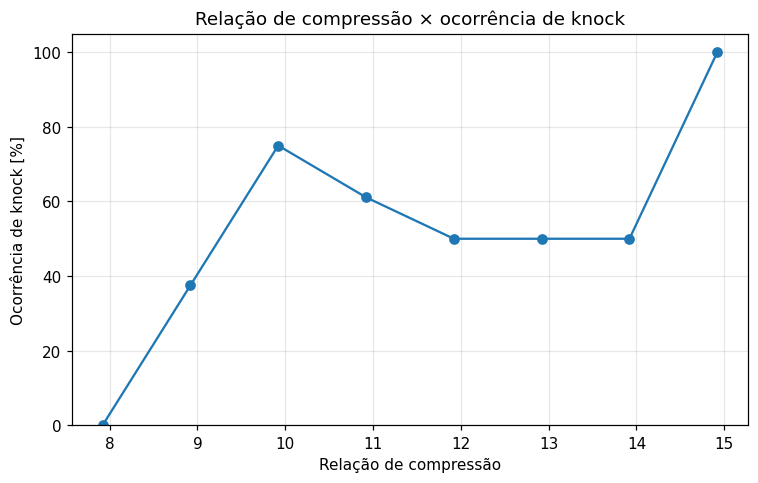

In [12]:
# ============================================================
# 11. Dispersões: Lambda × SEPO; avanço × MAPO; IMEP × KI;
#     RC × ocorrência de knock
# ============================================================
def dispersao_por_knock(x, y, titulo, xlabel, ylabel, arquivo):
    fig, eixo = plt.subplots(figsize=(7, 5))
    for classe, rotulo, marcador in [(0, "Sem knock", "o"), (1, "Com knock", "x")]:
        subconjunto = base_eda_valida[base_eda_valida["Knock"] == classe]
        eixo.scatter(subconjunto[x], subconjunto[y], alpha=0.75, label=rotulo, marker=marcador)
    eixo.set_title(titulo)
    eixo.set_xlabel(xlabel)
    eixo.set_ylabel(ylabel)
    eixo.legend()
    eixo.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PASTA_SAIDA / arquivo, bbox_inches="tight")
    plt.show()

if base_eda_valida[["Lambda", "SEPO"]].notna().any().all():
    dispersao_por_knock("Lambda", "SEPO", "Lambda × SEPO", "Lambda [-]", "SEPO [bar·deg]", "dispersao_lambda_sepo.png")

if base_eda_valida[["Avanco", "MAPO"]].notna().any().all():
    dispersao_por_knock("Avanco", "MAPO", "Avanço de ignição × MAPO", "Avanço [deg bTDCf]", "MAPO [bar]", "dispersao_avanco_mapo.png")

if "KI" in base_eda_valida.columns and base_eda_valida[["IMEP", "KI"]].notna().any().all():
    dispersao_por_knock("IMEP", "KI", "IMEP × índice de knock", "IMEP [bar]", "KI / DKI [-]", "dispersao_imep_ki.png")

# Relação de compressão × ocorrência de knock: taxa média de knock por RC.
taxa_knock_rc = base_eda_valida.groupby("RC", dropna=True)["Knock"].agg(["count", "sum", "mean"]).reset_index()
taxa_knock_rc.columns = ["RC", "n_ensaios", "n_knock", "taxa_knock"]
taxa_knock_rc["taxa_knock_pct"] = 100 * taxa_knock_rc["taxa_knock"]

print("Ocorrência de knock por relação de compressão:")
display(taxa_knock_rc)

fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.plot(taxa_knock_rc["RC"], taxa_knock_rc["taxa_knock_pct"], marker="o")
eixo.set_title("Relação de compressão × ocorrência de knock")
eixo.set_xlabel("Relação de compressão")
eixo.set_ylabel("Ocorrência de knock [%]")
eixo.set_ylim(bottom=0)
eixo.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "knock_por_rc.png", bbox_inches="tight")
plt.show()


## 10. Síntese automática para o relatório

Esta célula gera números objetivos que podem ser usados na interpretação da EDA.

In [13]:
# ============================================================
# 12. Síntese numérica da EDA
# ============================================================
n_total = len(base_eda)
n_validos = len(base_eda_valida)
n_knock = int((base_eda_valida["Knock"] == 1).sum())
percentual_knock = 100 * n_knock / n_validos if n_validos else np.nan

print("SÍNTESE DA EDA")
print(f"- Ensaios totais: {n_total}")
print(f"- Ensaios válidos considerados: {n_validos}")
print(f"- Ensaios com knock: {n_knock} ({percentual_knock:.1f}%)")
print(f"- Linhas duplicadas: {linhas_duplicadas}")
print(f"- Linhas com alguma incoerência física inicial: {indices_incoerentes.sum()}")

# Correlações de maior magnitude com a classe Knock.
if "Knock" in matriz_spearman.columns:
    ranking_knock = (
        matriz_spearman["Knock"]
        .drop("Knock", errors="ignore")
        .dropna()
        .sort_values(key=lambda serie: serie.abs(), ascending=False)
        .to_frame("Spearman com Knock")
    )
    print("\nRanking de associação monotônica com Knock (Spearman):")
    display(ranking_knock)
    ranking_knock.to_csv(PASTA_SAIDA / "ranking_spearman_knock.csv", encoding="utf-8-sig")

print(f"\nArquivos salvos na pasta: {PASTA_SAIDA.resolve()}")


SÍNTESE DA EDA
- Ensaios totais: 83
- Ensaios válidos considerados: 79
- Ensaios com knock: 38 (48.1%)
- Linhas duplicadas: 0
- Linhas com alguma incoerência física inicial: 0

Ranking de associação monotônica com Knock (Spearman):


,Spearman com Knock
MAPO,0.8121
IMEP,-0.8077
SEPO,0.8066
Avanco,-0.4828
RC,0.3895
Lambda,-0.2536
CA50,0.2533



Arquivos salvos na pasta: /mnt/data/resultados_eda
